# 분류로 시작해보자!

In [178]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# 타이타닉 데이터셋 로드 (실습)
train = pd.read_csv("titanic/train.csv")
test = pd.read_csv("titanic/test.csv")

In [ ]:
# 데이터셋의 형태 확인 (실습)
train.shape  # 891개 행과 12개의 열

(891, 12)

In [ ]:
# 데이터셋 형태 확인 (실습)
test.shape  # 419개의 행과 11개의 열

(418, 11)

In [ ]:
# 학습데이터의 결측치 확인 (실습)
print(train.isnull().sum())
print()

# 테스트 데이터의 결측치 확인 (실습)
print(test.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64


# Age 결측치 채우기

/var/folders/fz/nl6s3pmj3tj57mpffc5d1h080000gn/T/ipykernel_25868/4222946793.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train['Age'].fillna(train['Age'].mean(), inplace=True)


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

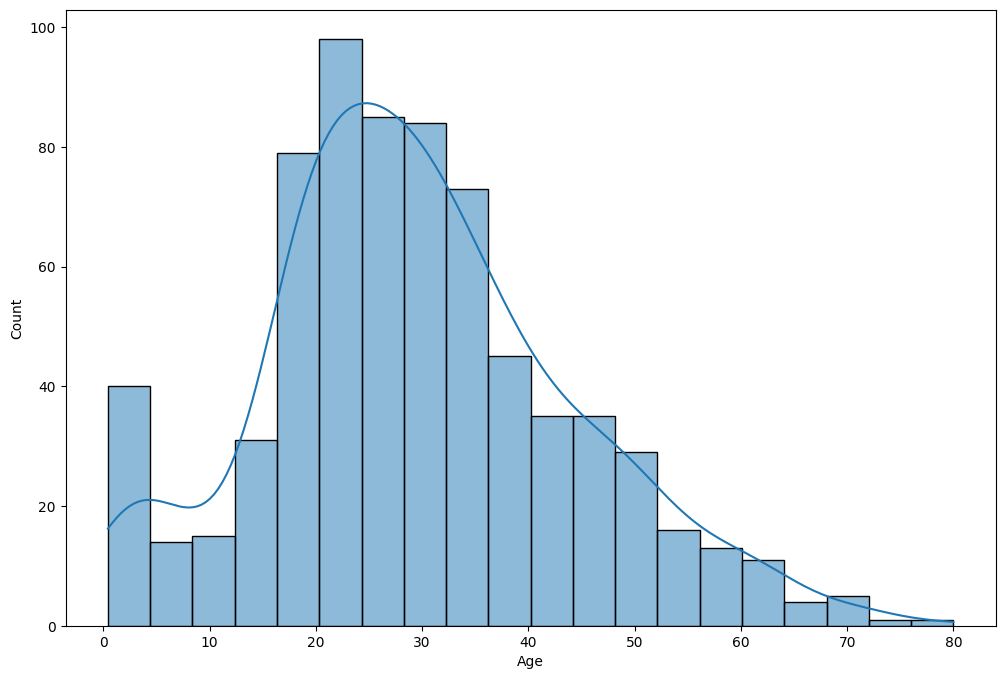

In [ ]:
# Age열의 결측치 확인 및 평균 대체 (실습)
plt.figure(figsize=(12, 8))
sns.histplot(train["Age"], kde=True)

# 정규분포와 유사한 분포를 가져 그냥 mean으로 대체 (실습)
train["Age"].fillna(train["Age"].mean(), inplace=True)
train.isnull().sum()  # 채워짐 확인 (실습)

In [ ]:
# test의 Age도 train과 동일하게 결측치를 채워줌 (실습)
test["Age"].fillna(test["Age"].mean(), inplace=True)
test.isnull().sum()  # 채워짐 확인 (실습)

/var/folders/fz/nl6s3pmj3tj57mpffc5d1h080000gn/T/ipykernel_25868/4091271777.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test['Age'].fillna(test['Age'].mean(), inplace=True)


PassengerId      0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

# Cabin 결측치 채우기

In [ ]:
# Cabin의 고유값 확인 (실습)
train["Cabin"].unique()

array([nan, 'C85', 'C123', 'E46', 'G6', 'C103', 'D56', 'A6',
       'C23 C25 C27', 'B78', 'D33', 'B30', 'C52', 'B28', 'C83', 'F33',
       'F G73', 'E31', 'A5', 'D10 D12', 'D26', 'C110', 'B58 B60', 'E101',
       'F E69', 'D47', 'B86', 'F2', 'C2', 'E33', 'B19', 'A7', 'C49', 'F4',
       'A32', 'B4', 'B80', 'A31', 'D36', 'D15', 'C93', 'C78', 'D35',
       'C87', 'B77', 'E67', 'B94', 'C125', 'C99', 'C118', 'D7', 'A19',
       'B49', 'D', 'C22 C26', 'C106', 'C65', 'E36', 'C54',
       'B57 B59 B63 B66', 'C7', 'E34', 'C32', 'B18', 'C124', 'C91', 'E40',
       'T', 'C128', 'D37', 'B35', 'E50', 'C82', 'B96 B98', 'E10', 'E44',
       'A34', 'C104', 'C111', 'C92', 'E38', 'D21', 'E12', 'E63', 'A14',
       'B37', 'C30', 'D20', 'B79', 'E25', 'D46', 'B73', 'C95', 'B38',
       'B39', 'B22', 'C86', 'C70', 'A16', 'C101', 'C68', 'A10', 'E68',
       'B41', 'A20', 'D19', 'D50', 'D9', 'A23', 'B50', 'A26', 'D48',
       'E58', 'C126', 'B71', 'B51 B53 B55', 'D49', 'B5', 'B20', 'F G63',
       'C62 C64',

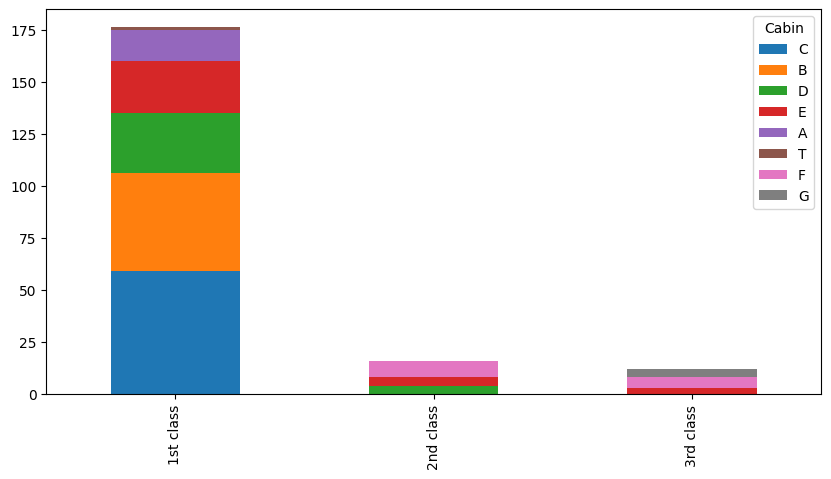

In [ ]:
# Cabin은 Pclass별로 가장 많이 탑승한 객실을 기준으로 결측치를 채워줌 (실습)
cabin_only = train[["Cabin", "Pclass"]].copy()
cabin_only["Cabin"] = cabin_only["Cabin"].str[:1]

# 객실별 탑승자 수를 확인하여 가장 많이 탑승한 객실을 기준으로 숫자 합치기
Pclass1 = cabin_only[cabin_only["Pclass"] == 1]["Cabin"].value_counts()  # 1등석의 객실
Pclass2 = cabin_only[cabin_only["Pclass"] == 2]["Cabin"].value_counts()  # 2등석의 객실
Pclass3 = cabin_only[cabin_only["Pclass"] == 3]["Cabin"].value_counts()  # 3등석의 객실

# 위에 데이터를 데이터프레임으로 합쳐줌
df = pd.DataFrame([Pclass1, Pclass2, Pclass3])

# pandas 자체에 함수 그리는 기능 kind = "bar", stacked = True(실습)
df.index = ["1st class", "2nd class", "3rd class"]
df.plot(kind="bar", stacked=True, figsize=(10, 5))
plt.show()

In [ ]:
# train의 Cabin 데이터 채우기 (실습)
train.loc[(train.Pclass == 1) & (train.Cabin.isnull()), "Cabin"] = "B"
train.loc[(train.Pclass == 2) & (train.Cabin.isnull()), "Cabin"] = "E"
train.loc[(train.Pclass == 3) & (train.Cabin.isnull()), "Cabin"] = "F"
train["Cabin"] = train["Cabin"].str.slice(0, 1)

# 채운 정보 확인 
train.isnull().sum()  # 채워짐

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       2
dtype: int64

In [ ]:
# test의 Cabin 결측치 채우기 (실습)
test.loc[(test.Pclass == 1) & (test.Cabin.isnull()), "Cabin"] = "B"
test.loc[(test.Pclass == 2) & (test.Cabin.isnull()), "Cabin"] = "E"
test.loc[(test.Pclass == 3) & (test.Cabin.isnull()), "Cabin"] = "F"
test["Cabin"] = test["Cabin"].str.slice(0, 1)

# 채운 정보 확인
test.isnull().sum()  # 채워짐

PassengerId    0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           1
Cabin          0
Embarked       0
dtype: int64

# Embarked

In [ ]:
# train의 Embarked null값 추가하기 (실습)
train["Embarked"].fillna(train["Embarked"].mode()[0], inplace=True)
train.isnull().sum()  # 채워짐

/var/folders/fz/nl6s3pmj3tj57mpffc5d1h080000gn/T/ipykernel_25868/1950336311.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train['Embarked'].fillna(train['Embarked'].mode()[0], inplace=True)


PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64

In [ ]:
# test의 Embarked null값 추가하기 (실습)
test["Embarked"].fillna(test["Embarked"].mode()[0], inplace=True)
test.isnull().sum()  # 채워짐

/var/folders/fz/nl6s3pmj3tj57mpffc5d1h080000gn/T/ipykernel_25868/1277729539.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test['Embarked'].fillna(test['Embarked'].mode()[0], inplace=True)


PassengerId    0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           1
Cabin          0
Embarked       0
dtype: int64

In [ ]:
# Fare의 결측치는 Fare의 평균값으로 채워줌 (실습)
test["Fare"].fillna(test["Fare"].mean(), inplace=True)

/var/folders/fz/nl6s3pmj3tj57mpffc5d1h080000gn/T/ipykernel_25868/3780432262.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test['Fare'].fillna(test['Fare'].mean(), inplace=True)


In [ ]:
# 최종 train 데이터를 X와 y로 나누기 (실습)
X = train.drop(["PassengerId", "Name", "Ticket", "Survived"], axis=1)
y = train["Survived"]


# Test 데이터는 PassengerId, Name, Ticket 열을 제외 
X_test = test.drop(["PassengerId", "Name", "Ticket"], axis=1)

# 스케일링 & 라벨링


In [ ]:
# train_test_split을 통해 학습 데이터와 검증 데이터를 나누기(실습)
from sklearn.model_selection import train_test_split

# test_size = 0.2, random_state=42 데이터 나누기(실습)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

X_train.shape, X_val.shape, y_train.shape, y_val.shape


((712, 8), (179, 8), (712,), (179,))

In [195]:
X_train

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
331,1,male,45.500000,0,0,28.5000,C,S
733,2,male,23.000000,0,0,13.0000,E,S
382,3,male,32.000000,0,0,7.9250,F,S
704,3,male,26.000000,1,0,7.8542,F,S
813,3,female,6.000000,4,2,31.2750,F,S
...,...,...,...,...,...,...,...,...
106,3,female,21.000000,0,0,7.6500,F,S
270,1,male,29.699118,0,0,31.0000,B,S
860,3,male,41.000000,2,0,14.1083,F,S
435,1,female,14.000000,1,2,120.0000,B,S


In [196]:
X_val

,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
709,3,male,29.699118,1,1,15.2458,F,C
439,2,male,31.000000,0,0,10.5000,E,S
840,3,male,20.000000,0,0,7.9250,F,S
720,2,female,6.000000,0,1,33.0000,E,S
39,3,female,14.000000,1,0,11.2417,F,C
...,...,...,...,...,...,...,...,...
433,3,male,17.000000,0,0,7.1250,F,S
773,3,male,29.699118,0,0,7.2250,F,C
25,3,female,38.000000,1,5,31.3875,F,S
84,2,female,17.000000,0,0,10.5000,E,S


In [197]:
y_train

331    0
733    0
382    0
704    0
813    0
      ..
106    1
270    0
860    0
435    1
102    0
Name: Survived, Length: 712, dtype: int64

In [198]:
y_val

709    1
439    0
840    0
720    1
39     1
      ..
433    0
773    0
25     1
84     1
10     1
Name: Survived, Length: 179, dtype: int64

In [ ]:
# 표준화 하기(실습)
from sklearn.preprocessing import StandardScaler

# 모델 넣고 fit하기(실습)
scaler = StandardScaler()
X_train[["Age", "Fare"]] = scaler.fit_transform(X_train[["Age", "Fare"]])
X_val[["Age", "Fare"]] = scaler.transform(X_val[["Age", "Fare"]])


# test 데이터에도 동일한 스케일링 적용(실습)
X_test[["Age", "Fare"]] = scaler.transform(X_test[["Age", "Fare"]])

In [ ]:
# 순서가 있는 애들은 라벨인코딩을.
# 순서가 없는 애들은 원핫 인코딩을 진행한다.

# cabin과 embarked는 순서가 없는 애들이므로 원핫인코딩을 진행한다.

from sklearn.preprocessing import OneHotEncoder

# 각 인코더 따로 만들기
encoder_cabin = OneHotEncoder(
    handle_unknown="ignore", sparse_output=False
)  # hadle_unknown='ignore'는 학습 데이터에 없는 값이 테스트 데이터에 있을 때 무시하도록 설정
encoder_embarked = OneHotEncoder(
    handle_unknown="ignore", sparse_output=False
)  # sparse_output=False는 희소 행렬이 아닌 일반 배열로 반환하도록 설정 걍 판다스로 붙이기 가능!

# Cabin 인코딩
cabin_encoded = encoder_cabin.fit_transform(X_train[["Cabin"]])
cabin_encoded_val = encoder_cabin.transform(X_val[["Cabin"]])
cabin_encoded_df = pd.DataFrame(
    cabin_encoded,
    columns=encoder_cabin.get_feature_names_out(["Cabin"]),
    index=X_train.index,
)
cabin_encoded_val_df = pd.DataFrame(
    cabin_encoded_val,
    columns=encoder_cabin.get_feature_names_out(["Cabin"]),
    index=X_val.index,
)

# Embarked 인코딩
embarked_encoded = encoder_embarked.fit_transform(X_train[["Embarked"]])
embarked_encoded_val = encoder_embarked.transform(X_val[["Embarked"]])
embarked_encoded_df = pd.DataFrame(
    embarked_encoded,
    columns=encoder_embarked.get_feature_names_out(["Embarked"]),
    index=X_train.index,
)
embarked_encoded_val_df = pd.DataFrame(
    embarked_encoded_val,
    columns=encoder_embarked.get_feature_names_out(["Embarked"]),
    index=X_val.index,
)

# 원래 열 삭제하고 인코딩된 열 붙이기
X_train = X_train.drop(["Cabin", "Embarked"], axis=1)
X_val = X_val.drop(["Cabin", "Embarked"], axis=1)

X_train = pd.concat([X_train, cabin_encoded_df, embarked_encoded_df], axis=1)
X_val = pd.concat([X_val, cabin_encoded_val_df, embarked_encoded_val_df], axis=1)

# test 데이터에도 동일한 인코딩 적용
cabin_encoded_test = encoder_cabin.transform(X_test[["Cabin"]])
embarked_encoded_test = encoder_embarked.transform(X_test[["Embarked"]])
cabin_encoded_test_df = pd.DataFrame(
    cabin_encoded_test,
    columns=encoder_cabin.get_feature_names_out(["Cabin"]),
    index=X_test.index,
)
embarked_encoded_test_df = pd.DataFrame(
    embarked_encoded_test,
    columns=encoder_embarked.get_feature_names_out(["Embarked"]),
    index=X_test.index,
)
X_test = X_test.drop(["Cabin", "Embarked"], axis=1)
X_test = pd.concat([X_test, cabin_encoded_test_df, embarked_encoded_test_df], axis=1)

# 최종적으로 인코딩된 train, validation, test 데이터 확인
print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)

X_train shape: (712, 17)
X_val shape: (179, 17)
X_test shape: (418, 17)


In [ ]:
# 성별은 남자는 1 여자는 0으로 변환(실습)
X_train["Sex"].replace({"male": 1, "female": 0}, inplace=True)
X_val["Sex"].replace({"male": 1, "female": 0}, inplace=True)

# test 데이터의 성별도 동일하게 변환(실습)
X_test["Sex"].replace({"male": 1, "female": 0}, inplace=True)

/var/folders/fz/nl6s3pmj3tj57mpffc5d1h080000gn/T/ipykernel_25868/877956053.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X_train['Sex'].replace({'male': 1,
/var/folders/fz/nl6s3pmj3tj57mpffc5d1h080000gn/T/ipykernel_25868/877956053.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_train['Se

# 모델 선정하고 Fit 해보기

In [ ]:
# logistic regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# 로지스틱 회귀 모델 정의하기(실습)
log_reg = LogisticRegression(max_iter=1000)  # max_iter는 반복 횟수를 늘려서 수렴을 보장
# 로지스틱 회귀 fit하기 (실습)
log_reg.fit(X_train, y_train)  # 학습 데이터로 모델 학습

# 검증 데이터로 예측(실습)
y_val_pred_log = log_reg.predict(X_val)

# 예측 결과 확인(실습)
print("Validation Predictions (Logistic Regression):", y_val_pred_log)

# 정확도 평가(실습)
accuracy_log = accuracy_score(y_val, y_val_pred_log)
print("Train Accuracy (Logistic Regression):", log_reg.score(X_train, y_train))
print("Validation Accuracy (Logistic Regression):", accuracy_log)



Train Accuracy (Logistic Regression): 0.8103932584269663
Validation Accuracy (Logistic Regression): 0.7988826815642458


In [ ]:
# 이번 시간에 새롭게 배우는 내용을 확인해보자!

from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score

# precision, recall, f1 (실습) average="binary"
precision = precision_score(
    y_val, y_val_pred_log, average="binary"
)  # 다중 클래스일 경우 average='macro' 또는 'weighted'
recall = recall_score(y_val, y_val_pred_log, average="binary")
f1 = f1_score(y_val, y_val_pred_log, average="binary")

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

# confusion matrix(실습)
conf_matrix = confusion_matrix(y_val, y_val_pred_log)
print("Confusion Matrix:\n", conf_matrix)

In [ ]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# 랜덤 포레스트 분류 모델 정의하기(실습)
rf_classify_model = RandomForestClassifier(n_estimators=100)  # n_estimators는 트리의 개수

# 랜덤 포레스트 분류 모델 학습하기(실습)
rf_classify_model.fit(X_train, y_train)  # 학습 데이터로 모델 학습

# 검증 데이터로 예측(실습)
y_val_pred_rf = rf_classify_model.predict(X_val)

# 예측 결과 확인
print("Validation Predictions (Random Forest):", y_val_pred_rf)

# 정확도 평가
accuracy_rf = accuracy_score(y_val, y_val_pred_rf)
print("Train Accuracy (Random Forest):", rf_classify_model.score(X_train, y_train))
print("Validation Accuracy (Random Forest):", accuracy_rf)


Train Accuracy (Random Forest): 0.9831460674157303
Validation Accuracy (Random Forest): 0.8044692737430168


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix

# precision, recall, f1 (실습) average="binary"로 설정
precision = precision_score(
    y_val, y_val_pred_rf, average="binary"
)  # 다중 클래스일 경우 average='macro' 또는 'weighted'
recall = recall_score(y_val, y_val_pred_rf, average="binary")
f1 = f1_score(y_val, y_val_pred_rf, average="binary")

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)


conf_matrix = confusion_matrix(y_val, y_val_pred_rf)
print("Confusion Matrix:\n", conf_matrix)

In [ ]:
# R² score
# 'r2'
# 기본값, 회귀 성능 평가
# Mean Squared Error
# 'neg_mean_squared_error'
# 작을수록 좋음 (음수로 반환됨)
# Mean Absolute Error
# 'neg_mean_absolute_error'
# 절대 오차 평균 (음수로 반환됨)

from sklearn.model_selection import cross_val_score

# 교차 검증 (accuracy 점수 사용)(실습)
accuracy_scores = cross_val_score(rf_classify_model, X, y, cv=5, scoring='accuracy')
print(accuracy_scores)

# 교차 검증 (recall 점수 사용)(실습)
recall_score = cross_val_score(rf_classify_model, X, y, scoring="accuracy", cv=5)
print(recall_score)


# 회귀로 실습해보자!

In [ ]:
# insurance 데이터셋 불러오기(실습)
df = pd.read_csv("insurance.csv")

In [ ]:
# insurance 데이터셋 정보 확인(실습)
df.info()

# 1338개 행과 7개의 열

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [ ]:
# 데이터셋 5개 행 확인(실습)
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
# 데이터 결측치 확인(실습)
df.isnull().sum()

# 준비한 데이터셋의 결측치가 없기 때문에 결측치 처리 실습은 생략할게용^^

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [ ]:
# 범주형 변수 전처리(실습)
from sklearn.preprocessing import LabelEncoder

# sex, smoker는 이진 클래스 변수이기 때문에 one-hot 인코딩(실습)
df["sex"] = df["sex"].map({"female": 0, "male": 1})
df["smoker"] = df["smoker"].map({"no": 0, "yes": 1})

# region은 다중 클래스 변수이기 때문에 label 인코딩
# LabelEncoder의 fit_transform 메서드를 사용하여 region을 숫자로 변환(실습)
df["region"] = LabelEncoder().fit_transform(df["region"])
df

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,3,16884.92400
1,18,1,33.770,1,0,2,1725.55230
2,28,1,33.000,3,0,2,4449.46200
3,33,1,22.705,0,0,1,21984.47061
4,32,1,28.880,0,0,1,3866.85520
...,...,...,...,...,...,...,...
1333,50,1,30.970,3,0,1,10600.54830
1334,18,0,31.920,0,0,0,2205.98080
1335,18,0,36.850,0,0,2,1629.83350
1336,21,0,25.800,0,0,3,2007.94500


In [ ]:
# 수치형 변수 전처리(실습)
from sklearn.preprocessing import StandardScaler

# 정규화모델 정의(실습)
scaler = StandardScaler()

# 수치형 변수 구분 (실습)
num_cols = ["age", "bmi", "children"]

# 수치형 변수 스케일링 (실습)
df[num_cols] = scaler.fit_transform(df[num_cols])
df

,age,sex,bmi,children,smoker,region,charges
0,-1.438764,0,-0.453320,-0.908614,1,3,16884.92400
1,-1.509965,1,0.509621,-0.078767,0,2,1725.55230
2,-0.797954,1,0.383307,1.580926,0,2,4449.46200
3,-0.441948,1,-1.305531,-0.908614,0,1,21984.47061
4,-0.513149,1,-0.292556,-0.908614,0,1,3866.85520
...,...,...,...,...,...,...,...
1333,0.768473,1,0.050297,1.580926,0,1,10600.54830
1334,-1.509965,0,0.206139,-0.908614,0,0,2205.98080
1335,-1.509965,0,1.014878,-0.908614,0,2,1629.83350
1336,-1.296362,0,-0.797813,-0.908614,0,3,2007.94500


In [ ]:
# train_test_split을 통해 학습 데이터와 검증 데이터를 나누기
from sklearn.model_selection import train_test_split

# train, validate로 정보 나누기 (실습)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# 출력해서 형태 확인해보기 (실습)
X_train.shape, X_val.shape, y_train.shape, y_val.shape


((1070, 6), (268, 6), (1070,), (268,))

In [ ]:
# 랜덤 포레스트 회귀 모델
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 랜덤 포레스트 회귀 모델 정의, n_estimators=100, random_state=42 (실습)
rf_regression_model = RandomForestRegressor(n_estimators=100, random_state=42)

# 랜덤 포레스트 회귀 모델 학습하기(실습)
rf_regression_model.fit(X_train, y_train)

# 검증 데이터로 예측(실습)
y_val_pred_rf = rf_regression_model.predict(X_val)

# 예측 결과 확인(실습)
print("Validation Predictions (Random Forest):", y_val_pred_rf)

# 모델 성능 평가(실습)
mse_rf = mean_squared_error(y_val, y_val_pred_rf)
rmse_rf = np.sqrt(mse_rf)
mae_rf = mean_absolute_error(y_val, y_val_pred_rf)
r2_rf = r2_score(y_val, y_val_pred_rf)

print("MSE:", mse_rf)
print("RMSE:", rmse_rf)
print("MAE:", mae_rf)
print("R² Score:", r2_rf)

MSE: 20827913.205296144
RMSE: 4563.760861975148
MAE: 2514.888056629137
R² Score: 0.8658416529065179


In [ ]:
# R² score
# 'r2'
# 기본값, 회귀 성능 평가
# Mean Squared Error
# 'neg_mean_squared_error'
# 작을수록 좋음 (음수로 반환됨)
# Mean Absolute Error
# 'neg_mean_absolute_error'
# 절대 오차 평균 (음수로 반환됨)

from sklearn.model_selection import cross_val_score

# 교차 검증 (R^2 점수 사용)(실습)
r2_scores = cross_val_score(estimator=rf_regression_model, X=X, y=y, cv=5, scoring='r2')
print(r2_scores)

# scoring="neg_mean_squared_error" (실습)
mse_score = cross_val_score(estimator=rf_regression_model, X=X, y=y, scoring="neg_mean_squared_error", cv=5)
print(mse_score)


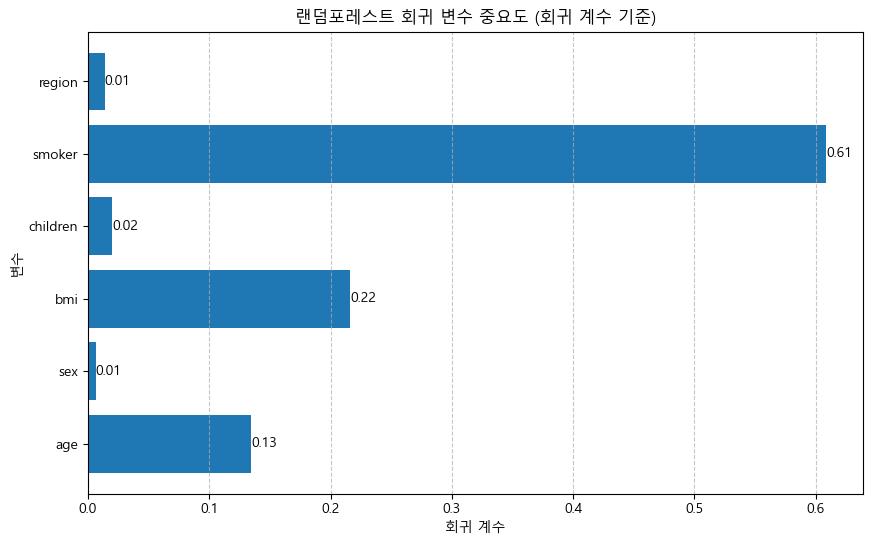

In [ ]:
# 랜덤포레스트 회귀 모델의 변수 중요도 확인 (실습)
features = X.columns
coefficients = rf_regression_model.feature_importances_

# 시각화 (실습)
plt.figure(figsize=(10, 6))
plt.barh(features, coefficients)
plt.grid(axis="x", linestyle="--", alpha=0.7)
for i, v in enumerate(coefficients):
    plt.text(v, i, f"{v:.2f}", va="center", fontsize=10)
plt.title("랜덤포레스트 회귀 변수 중요도 (회귀 계수 기준)")
plt.xlabel("회귀 계수")
plt.ylabel("변수")
plt.show()